In [1]:
# import stuff
import asymmetree.treeevolve as te
from asymmetree.visualization.tree_vis import visualize, assign_colors
import bmg_fun
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout
from collections import defaultdict
import random
import matplotlib.gridspec as gridspec
import insert_hybrid
from asymmetree.analysis.best_matches import lrt_from_tree
import BICcherry
from simplifying_operations import beam_search_step
import numpy as np
from bmg_Tony import bmg

In [2]:
# set seed
# Setze den Seed für Pythons Standard-Zufallsfunktionen
random.seed(3)
# Setze den Seed für NumPys Zufallsfunktionen (wichtig für AsymmeTree)
np.random.seed(3)

# species tree
S = te.species_tree_n_age(
    4, 1.0, contraction_probability=0.0, contraction_proportion=0.2, contraction_bias="exponential"
)
# gene tree
T = te.dated_gene_tree(
    S, dupl_rate=1.0, loss_rate=0, hgt_rate=0.2, gc_rate=0.2, prohibit_extinction="per_species", dupl_polytomy=0.5
)
# prune all loss branches and the planted root
observable_gene_tree = te.prune_losses(T)

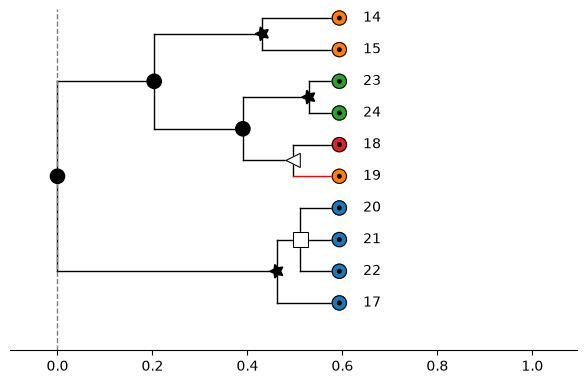

In [3]:
# get color dicts
species_colors, gene_colors = assign_colors(S, observable_gene_tree)
# visualize asymetree tree
visualize(observable_gene_tree, color_dict=gene_colors) 

In [4]:
# convert to networkx
tree_to_nx = bmg_fun.convert_to_nx(observable_gene_tree)
network = insert_hybrid.insertHybrid(tree_to_nx, 5)

Es wurde ein Hybrid zwischen node 1 und node 6 eingefügt und dieser wurde mit Node 4 verbunden
Es wurde ein Hybrid zwischen node 11 und node 19 eingefügt und dieser wurde mit Node 14 verbunden
Es wurde ein Hybrid zwischen node 8 und node 14 eingefügt und dieser wurde mit Node 13 verbunden
Es wurde ein Hybrid zwischen node 1 und node 2 eingefügt und dieser wurde mit Node 23 verbunden
Es wurde ein Hybrid zwischen node 25 und node 6 eingefügt und dieser wurde mit Node 21 verbunden


In [5]:
#print(tree_to_nx.nodes(data=True))

In [6]:
# reverse dict so every color has a list of leaves attached to it, for visualization
color_to_keys = defaultdict(list)
for key, color in gene_colors.items():
    color_to_keys[tuple(color)].append(key)

Text(0.5, 1.0, 'Hybrid Network')

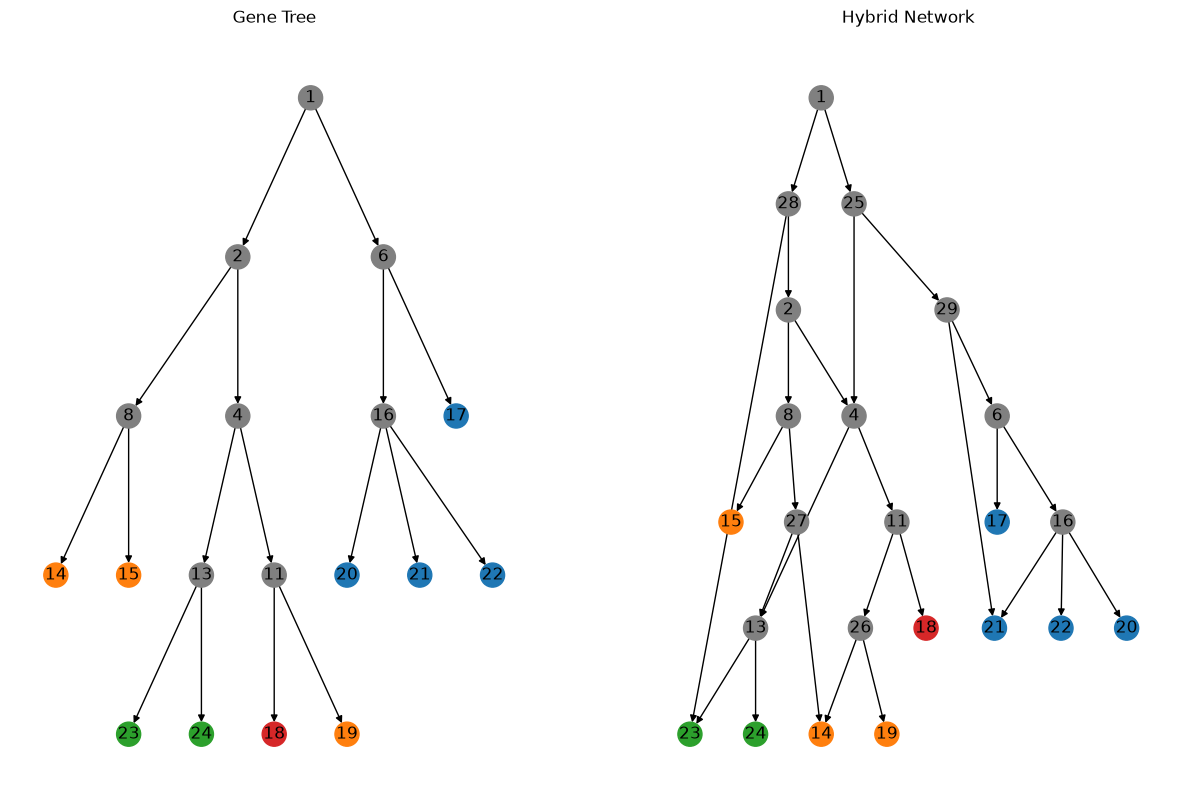

In [7]:
# gene color dict turn keys to strings
gene_colors_str = {str(k): v for k, v in gene_colors.items()}

# visualize tree and network
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

pos = graphviz_layout(tree_to_nx, prog="dot")
nodes_list = [v for v in tree_to_nx.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]

nx.draw(tree_to_nx, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0])
axes[0].set_title("Gene Tree")


pos = graphviz_layout(network, prog="dot")
nodes_list = [v for v in network.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(network, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[1])
axes[1].set_title("Hybrid Network")

# 02 Simplification of explaining networks
Construct tree-BMGs (G, σ) from (AsymmeTree-generated) trees and compute their least resolved trees T . This is the target.

In [8]:
# BMGs mit Tonys Funktion
BMG_tree_tony = bmg(tree_to_nx)
BMG_network_tony = bmg(network, mode="weak")


Text(0.5, 1.0, 'Network BMG Tony')

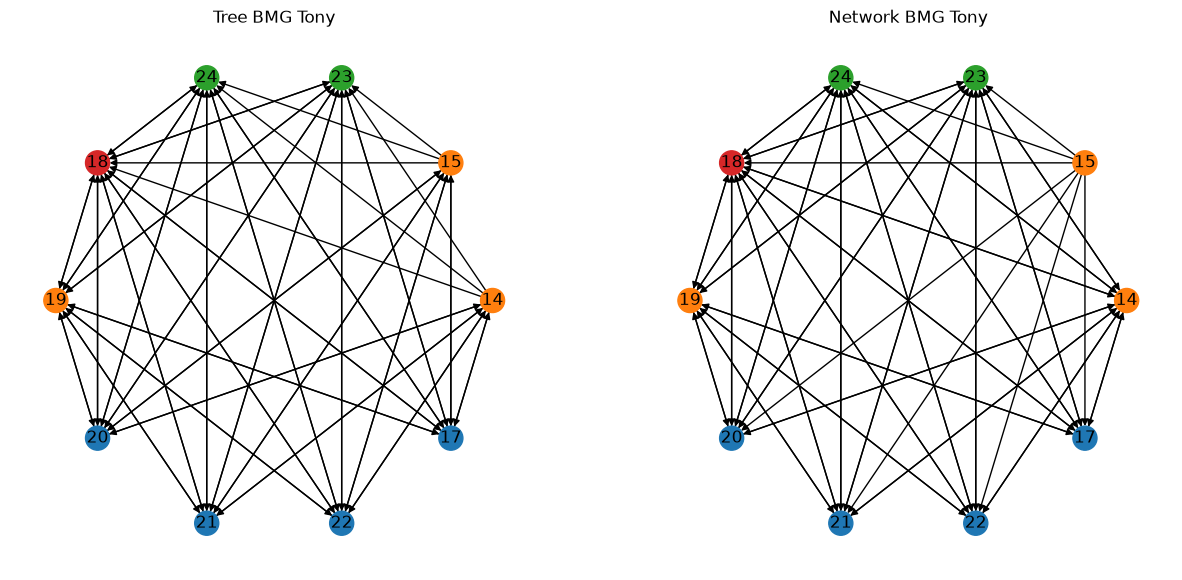

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Nach Tonys Funktion
nodes_list = [v for v in BMG_tree_tony.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BMG_tree_tony, nx.circular_layout(BMG_tree_tony), nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Tree BMG Tony")

# network BMG
nodes_list = [v for v in BMG_network_tony.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BMG_network_tony, nx.circular_layout(BMG_network_tony), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)
axes[1].set_title("Network BMG Tony")
    


## 2b Take the tree-BMGs from (a) and construct the BIC-cherry+expansion explanations

In [10]:
# ignore least resolved tree for now
# we need a function for that!!!!
bic_cherry_tree = BICcherry.BICcherry(BMG_network_tony)

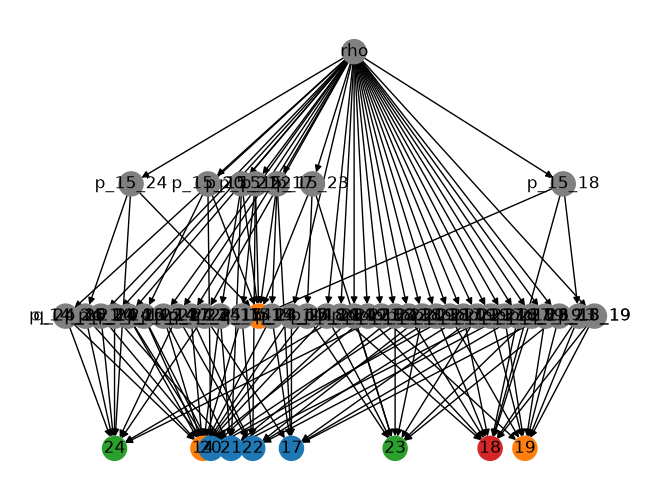

In [11]:
# turn LRT into networkx graph
#lrt_to_nx = bmg_fun.convert_to_nx(lrt)
fig = plt.figure()
pos = graphviz_layout(bic_cherry_tree, prog="dot")

nodes_list = [v for v in bic_cherry_tree.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(bic_cherry_tree, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels=True)

In [12]:
print("Weak BMGs equal? ", nx.utils.graphs_equal(BMG_network_tony, bmg(bic_cherry_tree, mode="weak")))
print("Weak BMGs equal? ", nx.utils.graphs_equal(bmg(network, mode="strong"), bmg(bic_cherry_tree, mode="strong")))

Weak BMGs equal?  True
Weak BMGs equal?  True


## Up is Down
(c) Implement graph editing by “pulling up” or “pulling down” edges, and removing vertices with the same parents and children, as described in class.

(d) Check both for single moves and combinations of a small number of moves whether the modified network (N ′ , σ) has the same (weak) best match graph as (N, σ).

In [13]:
# turn gene_color dict keys into strings
#gene_colors_str = {str(key):value for key,value in gene_colors.items()} # already done so further above
trees_list = beam_search_step([bic_cherry_tree], gene_colors_str, step_size = 1)

Finished step 1/1


In [16]:
print("The BIC cherry network is a ", bic_cherry_tree)
for tree in trees_list:
    print(tree)

The BIC cherry network is a  DiGraph with 53 nodes and 126 edges
DiGraph with 53 nodes and 125 edges
DiGraph with 54 nodes and 127 edges
DiGraph with 54 nodes and 127 edges
DiGraph with 53 nodes and 125 edges
DiGraph with 54 nodes and 127 edges
DiGraph with 54 nodes and 127 edges
DiGraph with 53 nodes and 125 edges
DiGraph with 54 nodes and 127 edges
DiGraph with 54 nodes and 127 edges
DiGraph with 53 nodes and 125 edges


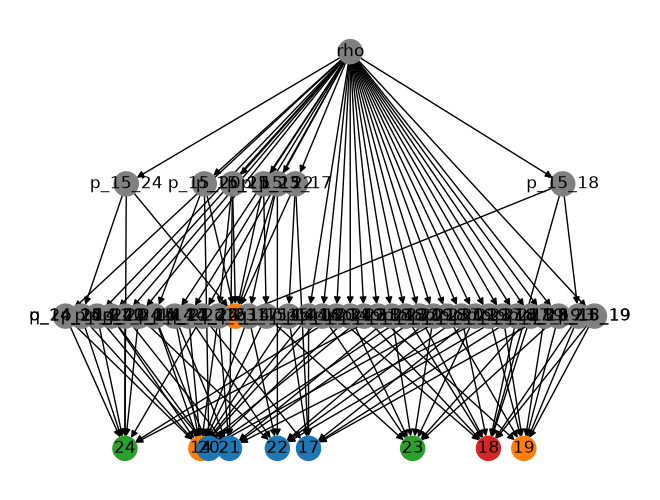

In [15]:
sel_tree = trees_list[0]
pos = graphviz_layout(sel_tree, prog="dot")
nodes_list = [v for v in sel_tree.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(sel_tree, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels=True)

# TODOs
**DONE** Correct BMG function for networks
- Improve efficiency of beam_search -> develop heuristics (?)